    ID                             Name Sex   Age  Height  Weight   Team  NOC  \
0  281                   S. Abdul Hamid   M   NaN     NaN     NaN  India  IND   
1  281                   S. Abdul Hamid   M   NaN     NaN     NaN  India  IND   
2  512  Shiny Kurisingal Abraham-Wilson   F  19.0   167.0    53.0  India  IND   
3  512  Shiny Kurisingal Abraham-Wilson   F  19.0   167.0    53.0  India  IND   
4  512  Shiny Kurisingal Abraham-Wilson   F  23.0   167.0    53.0  India  IND   

         Games  Year  Season         City      Sport  \
0  1928 Summer  1928  Summer    Amsterdam  Athletics   
1  1928 Summer  1928  Summer    Amsterdam  Athletics   
2  1984 Summer  1984  Summer  Los Angeles  Athletics   
3  1984 Summer  1984  Summer  Los Angeles  Athletics   
4  1988 Summer  1988  Summer        Seoul  Athletics   

                                    Event Medal  
0      Athletics Men's 110 metres Hurdles   NaN  
1      Athletics Men's 400 metres Hurdles   NaN  
2            Athletics Wom

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_3795/2923141318.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Cluster counts:
Cluster
0    794
2    345
1    269
Name: count, dtype: int64

Clustered data:
                                           clean_text  Cluster
0   abdul hamid india ind summer summer amsterdam ...        1
1   abdul hamid india ind summer summer amsterdam ...        1
2   shiny kurisingal abrahamwilson f india ind sum...        1
3   shiny kurisingal abrahamwilson f india ind sum...        1
4   shiny kurisingal abrahamwilson f india ind sum...        1
5   shiny kurisingal abrahamwilson f india ind sum...        1
6   shiny kurisingal abrahamwilson f india ind sum...        1
7   shiny kurisingal abrahamwilson f india ind sum...        1
8   sharath kamal achanta india ind summer summer ...        0
9   sharath kamal achanta india ind summer summer ...        0
10  sharath kamal achanta india ind summer summer ...        0
11  badathala adisekhar india ind summer summer ba...        0
12  badathala adisekhar india ind summer summer at...        0
13  mirza najib aga ind

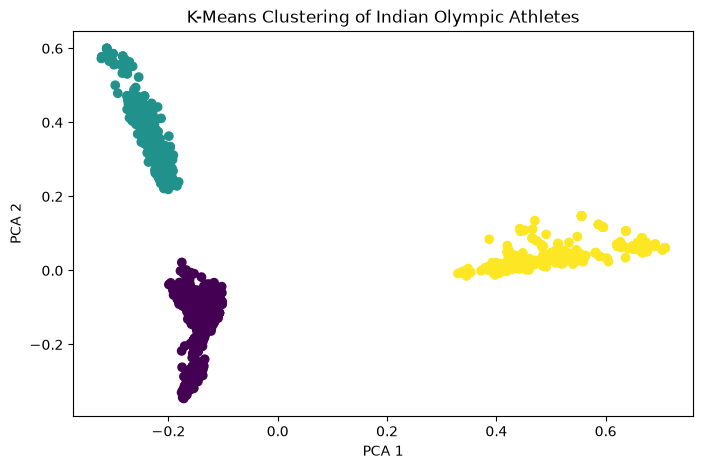

In [1]:
# 1. Import libraries
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Load dataset
df = pd.read_csv("Olympic_Athletes_India.csv")
print(df.head())
print(df.shape)

# 3. Combine text columns
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").agg(" ".join, axis=1)

# 4. NLP cleaning
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text.lower())
    return " ".join(w for w in text.split() if w not in stop_words)

df["clean_text"] = df["text"].apply(clean)

# 5. TF-IDF
tfidf = TfidfVectorizer(max_features=500)
X = tfidf.fit_transform(df["clean_text"])

# 6. K-Means
k = 3
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

# 7. Show results
print("\nCluster counts:")
print(df["Cluster"].value_counts())

print("\nClustered data:")
print(df[["clean_text", "Cluster"]].head(20))

# 8. Visualize clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering of Indian Olympic Athletes")
plt.show()

# 9. Save result
df.to_csv("Olympic_Athletes_India_Clustered.csv", index=False)